In [34]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langchain.chat_models import init_chat_model
from typing import List, Optional, TypedDict, Annotated
import operator
from dotenv import load_dotenv
from pydantic import BaseModel, Field

# Load environmental variables from .env
load_dotenv()

True

In [35]:
llm = init_chat_model("gpt-4o-mini")


## **Define state and create a graph**

In [36]:
class GState(BaseModel):
    messages: Annotated[list[AnyMessage], operator.add]
    city: str = Field(description="City name.", default="")
    interests: Annotated[List[str], operator.add] =  Field(description="Short list of interests - 3-5 elements")
    activities: Annotated[List[str], operator.add] = Field(description="List of activities.")
    sights: Annotated[List[str], operator.add] = Field(description="List of interesting places")

graph = StateGraph(GState)



##**Nodes**

In [37]:
def collect_preferences(state: GState) -> GState:
    """Extract city name and what user likes from the initial message"""

    class RespStructure(BaseModel):
        """Structured output definition"""
        city: str = Field(description="City name", default="")
        interests: List[str] = Field(description="List of areas of interests that user likes")

    text = state.messages[-1].content if state.messages else ""
    prompt = f"""
From the user input (may be empty):
<user_input>
{text}
</user_input>

extract information about the city name and user's interests.
"""
    ai = llm.with_structured_output(RespStructure).invoke(prompt)
    state.city = ai.city
    state.interests = ai.interests
    return state

def ask_activities(state: GState) -> GState:
    prompt = f"User likes {', '.join(state.interests)}. City: {state.city}. Suggest 3 activities."
    out = llm.invoke(prompt).content.split("\n")
    state.activities = state.activities + [x for x in out if x.strip()]
    return state

def ask_sights(state: GState) -> GState:
    prompt = f"Suggest the most interesting locations to see in {state.city}: 3 suggestions."
    out = llm.invoke(prompt).content.split("\n")
    state.sights = state.sights + [x for x in out if x.strip()]
    return state

def compose_answer(state: GState) -> GState:
    answer = (
        f"City: {state.city}\n"
        f"Interests: {', '.join(state.interests)}\n"
        f"Activities:\n- " + "\n- ".join(state.activities) + "\n"
        f"Iteresting locations:\n- " + "\n- ".join(state.sights)
    )
    state.messages = state.messages + [AIMessage(answer)]
    return state



##Create graph layout

In [38]:
graph.add_node("collect_preferences", collect_preferences)
graph.add_node("ask_activities", ask_activities)
graph.add_node("ask_sights", ask_sights)
graph.add_node("compose_answer", compose_answer)

# 4) Krawędzie – najprostszy liniowy przepływ
graph.set_entry_point("collect_preferences")
graph.add_edge("collect_preferences", "ask_activities")
graph.add_edge("ask_activities", "ask_sights")
graph.add_edge("ask_sights", "compose_answer")
graph.add_edge("compose_answer", END)

app = graph.compile()




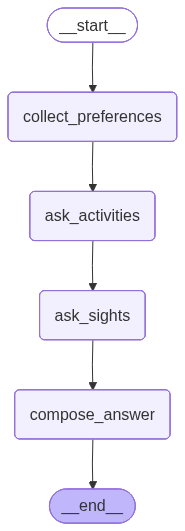

In [39]:
# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [40]:
initial = GState(
    messages = [HumanMessage("I am interested in sport photography and street food. I will visit Berlin.")],
    city = "",
    interests = [],
    activities = [],
    sights = []
)
final_result = app.invoke(initial)
print(final_result["messages"][-1].content)

City: Berlin
Interests: sport photography, street food, sport photography, street food, sport photography, street food, sport photography, street food
Activities:
- Here are three activities in Berlin that combine your interests in sport photography and street food:
- 1. **Street Food Markets**: Visit one of Berlin's vibrant street food markets, such as Markthalle Neun or Street Food auf Achse. These markets offer a diverse range of international street food and provide excellent opportunities for photography. Capture the colors and textures of the food, the chefs at work, and the lively atmosphere. Don't forget to savor some delicious bites while you're there!
- 2. **Catch a Local Sports Event**: Attend a local sports event, such as a basketball game at the Mercedes-Benz Arena or a football match featuring a Berlin team like Hertha BSC. These events can provide dynamic action shots and a lively crowd atmosphere. The excitement of the fans and the movement on the field or court can mak